# **Problem Statement**


---

#### **Business Context**  
Understanding customer personality and behavior is pivotal for businesses to enhance customer satisfaction and increase revenue. Segmentation based on a customer's personality, demographics, and purchasing behavior allows companies to create tailored marketing campaigns, improve customer retention, and optimize product offerings.  

A leading retail company with a rapidly growing customer base seeks to gain deeper insights into their customers' profiles. The company recognizes that understanding customer personalities, lifestyles, and purchasing habits can unlock significant opportunities for personalizing marketing strategies and creating loyalty programs. These insights can help address critical business challenges, such as improving the effectiveness of marketing campaigns, identifying high-value customer groups, and fostering long-term relationships with customers.  

With the competition intensifying in the retail space, moving away from generic strategies to more targeted and personalized approaches is essential for sustaining a competitive edge.  

---

#### **Objective**  
In an effort to optimize marketing efficiency and enhance customer experience, the company has embarked on a mission to identify distinct customer segments. By understanding the characteristics, preferences, and behaviors of each group, the company aims to:  
1. Develop personalized marketing campaigns to increase conversion rates.  
2. Create effective retention strategies for high-value customers.  
3. Optimize resource allocation, such as inventory management, pricing strategies, and store layouts.  

As a data scientist tasked with this project, your responsibility is to analyze the given customer data, apply machine learning techniques to segment the customer base, and provide actionable insights into the characteristics of each segment.  

---

#### **Data Dictionary**  
The dataset includes historical data on customer demographics, personality traits, and purchasing behaviors. Key attributes are:  

1. **Customer Information**  
   - **ID:** Unique identifier for each customer.  
   - **Year_Birth:** Customer's year of birth.  
   - **Education:** Education level of the customer.  
   - **Marital_Status:** Marital status of the customer.  
   - **Income:** Yearly household income (in dollars).  
   - **Kidhome:** Number of children in the household.  
   - **Teenhome:** Number of teenagers in the household.  
   - **Dt_Customer:** Date when the customer enrolled with the company.  
   - **Recency:** Number of days since the customer’s last purchase.  
   - **Complain:** Whether the customer complained in the last 2 years (1 for yes, 0 for no).  

2. **Spending Information (Last 2 Years)**  
   - **MntWines:** Amount spent on wine.  
   - **MntFruits:** Amount spent on fruits.  
   - **MntMeatProducts:** Amount spent on meat.  
   - **MntFishProducts:** Amount spent on fish.  
   - **MntSweetProducts:** Amount spent on sweets.  
   - **MntGoldProds:** Amount spent on gold products.  

3. **Purchase and Campaign Interaction**  
   - **NumDealsPurchases:** Number of purchases made using a discount.  
   - **AcceptedCmp1:** Response to the 1st campaign (1 for yes, 0 for no).  
   - **AcceptedCmp2:** Response to the 2nd campaign (1 for yes, 0 for no).  
   - **AcceptedCmp3:** Response to the 3rd campaign (1 for yes, 0 for no).  
   - **AcceptedCmp4:** Response to the 4th campaign (1 for yes, 0 for no).  
   - **AcceptedCmp5:** Response to the 5th campaign (1 for yes, 0 for no).  
   - **Response:** Response to the last campaign (1 for yes, 0 for no).  

4. **Shopping Behavior**  
   - **NumWebPurchases:** Number of purchases made through the company’s website.  
   - **NumCatalogPurchases:** Number of purchases made using catalogs.  
   - **NumStorePurchases:** Number of purchases made directly in stores.  
   - **NumWebVisitsMonth:** Number of visits to the company’s website in the last month.  

# **Let's start coding!**

## **Importing necessary libraries**

In [ ]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
# to compute distances
from scipy.spatial.distance import cdist, pdist

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# to visualize the elbow curve and silhouette scores
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# to suppress warnings
import warnings

import time

warnings.filterwarnings("ignore")

## **Loading the data**

In [ ]:
# uncomment and run the following line if using Google Colab
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# loading data into a pandas dataframe
df = pd.read_csv("/content/sample_data/Customer_Personality_Segmentation.csv", sep="\t")

## **Data Overview**

#### **Question 1**: What are the data types of all the columns?

In [ ]:
print("Q1: Data Types\n", df.dtypes, "\n")

Q1: Data Types
 ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object 



##### **Observations:**

#### **Question 2:** Check the statistical summary of the data. What is the average household income?

In [ ]:
summary = df.describe(include='all')
mean_income = df['Income'].dropna().mean()
print(summary)
print(f"Average Income: ${mean_income:.2f}")

                  ID   Year_Birth   Education Marital_Status         Income  \
count    2240.000000  2240.000000        2240           2240    2216.000000   
unique           NaN          NaN           5              8            NaN   
top              NaN          NaN  Graduation        Married            NaN   
freq             NaN          NaN        1127            864            NaN   
mean     5592.159821  1968.805804         NaN            NaN   52247.251354   
std      3246.662198    11.984069         NaN            NaN   25173.076661   
min         0.000000  1893.000000         NaN            NaN    1730.000000   
25%      2828.250000  1959.000000         NaN            NaN   35303.000000   
50%      5458.500000  1970.000000         NaN            NaN   51381.500000   
75%      8427.750000  1977.000000         NaN            NaN   68522.000000   
max     11191.000000  1996.000000         NaN            NaN  666666.000000   

            Kidhome     Teenhome Dt_Customer      R

##### **Observations:**
the Average Income is $52,247.25

#### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method

In [ ]:
missing = df.isnull().sum()
print(missing)
# Impute Income median (24 missing):
median_income = df['Income'].median()
df['Income'].fillna(median_income, inplace=True)

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64


##### **Observations:**

#### **Question 4**: Are there any duplicates in the data?

In [ ]:
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")

Duplicate rows: 0


##### **Observations:**

## **Exploratory Data Analysis**

### Univariate Analysis

#### **Question 5:** Explore all the variables and provide observations on their distributions. (histograms and boxplots)

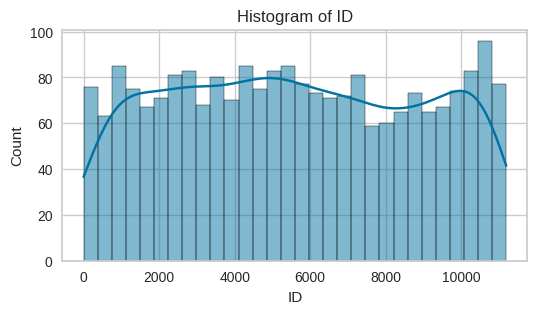

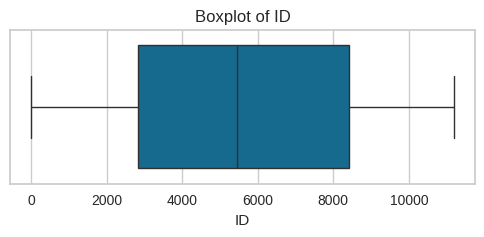

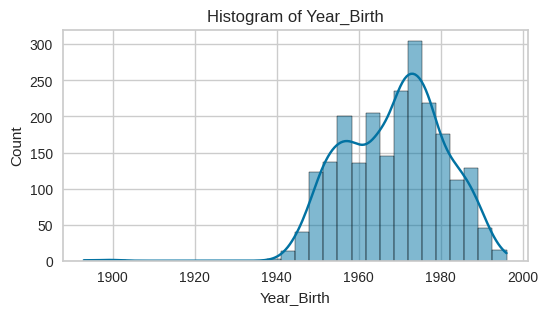

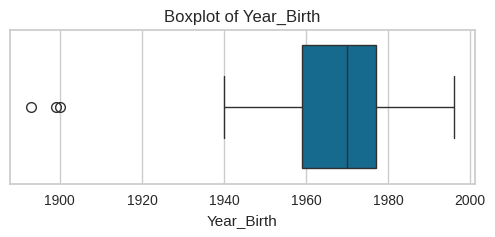

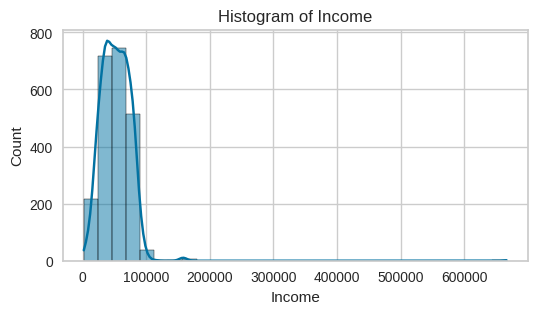

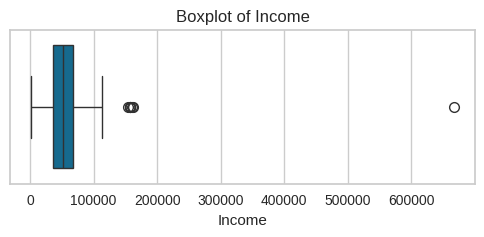

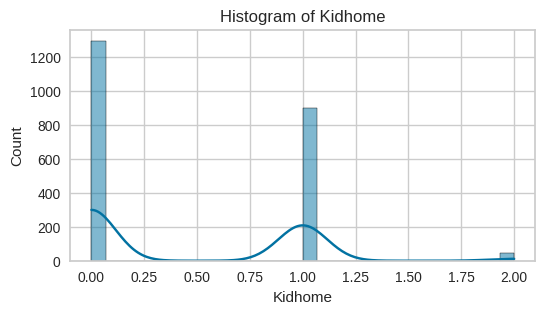

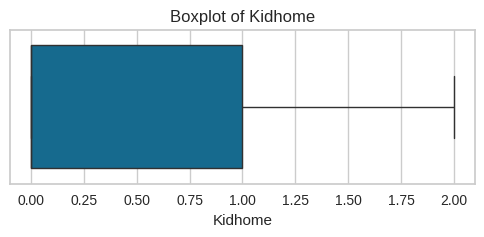

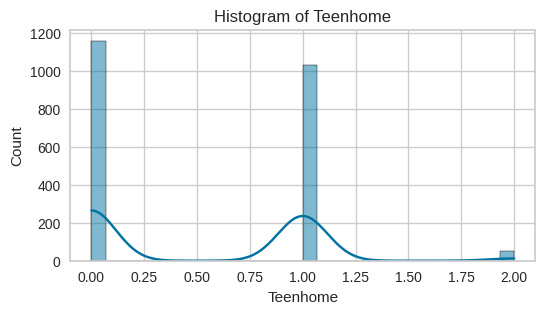

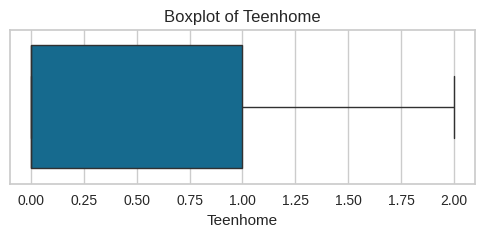

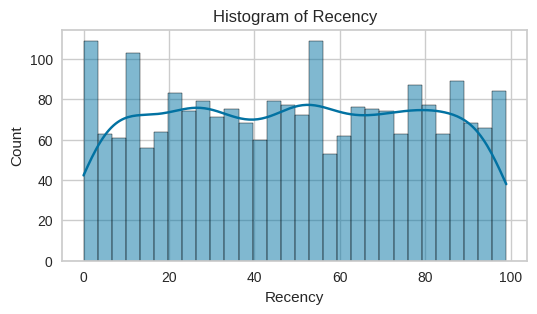

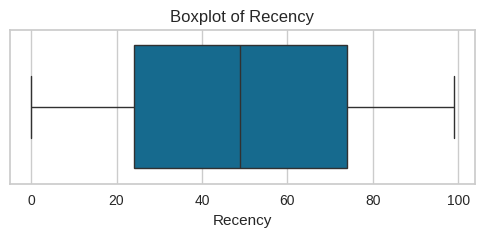

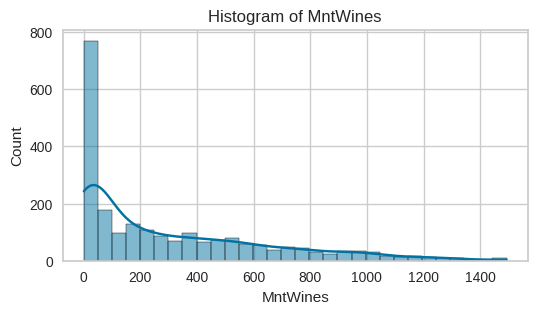

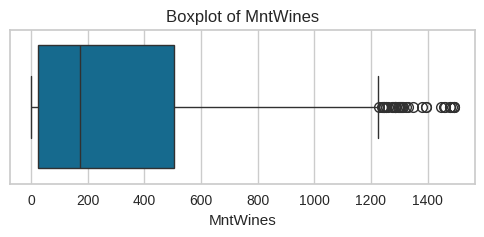

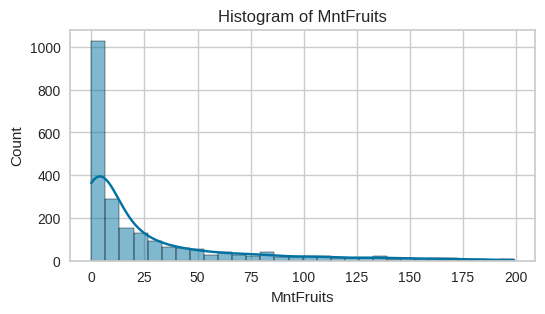

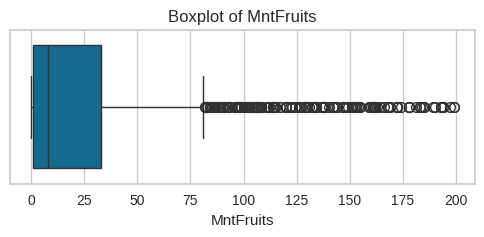

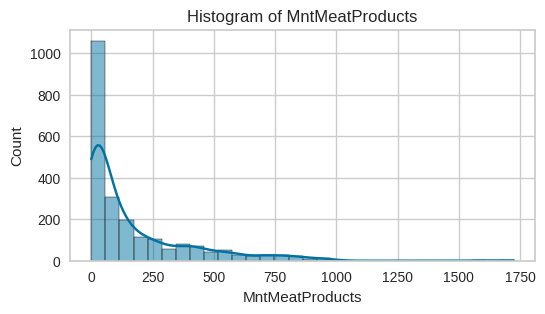

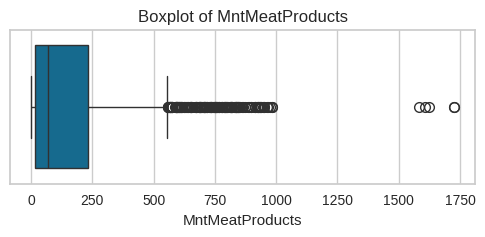

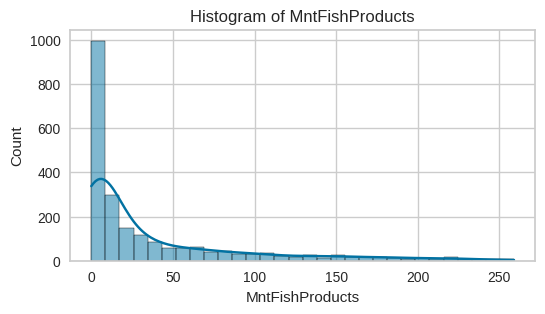

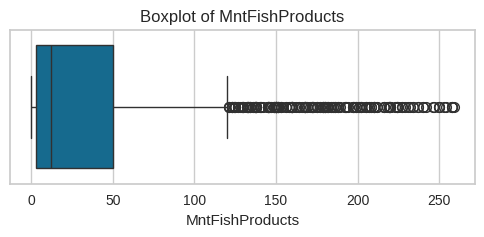

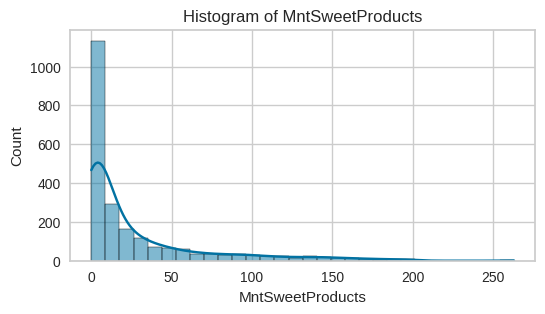

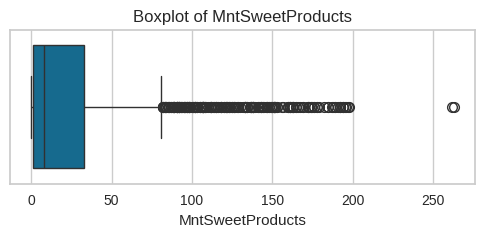

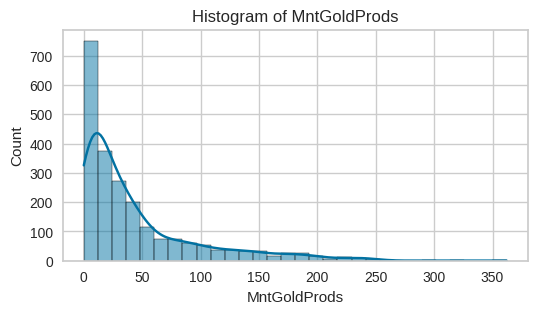

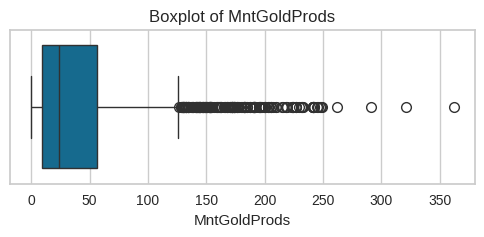

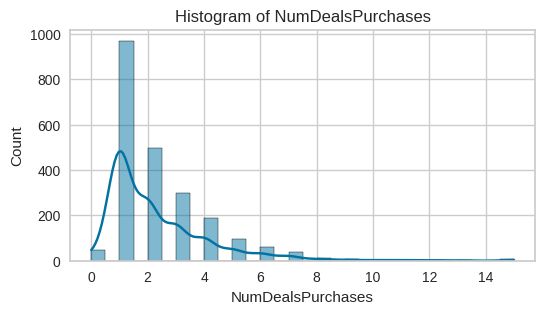

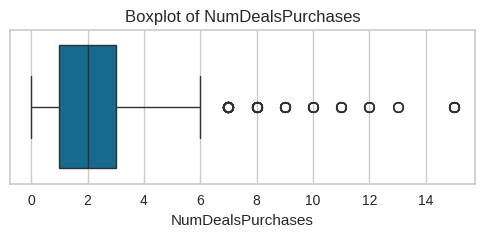

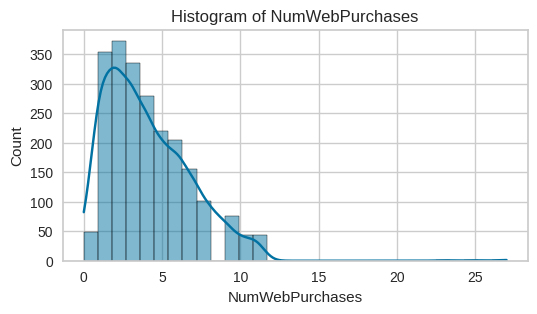

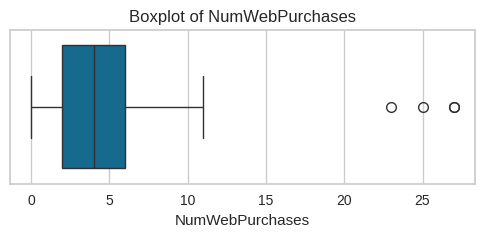

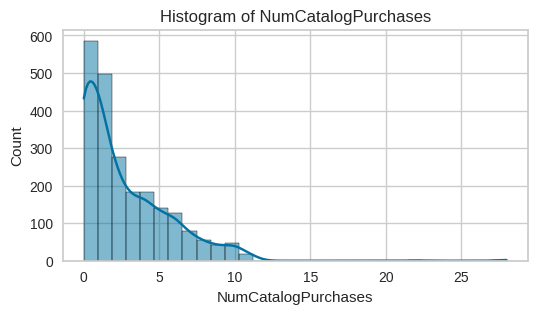

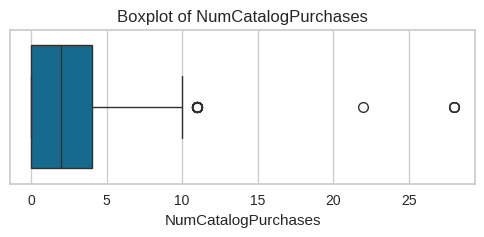

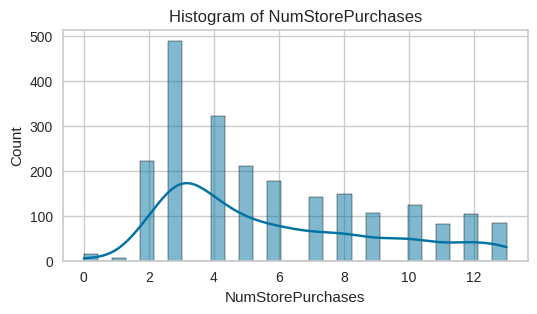

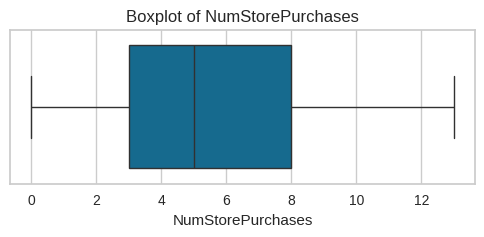

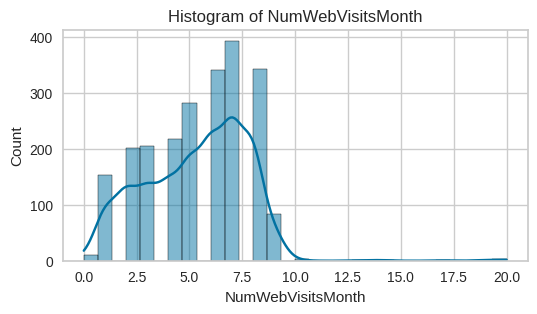

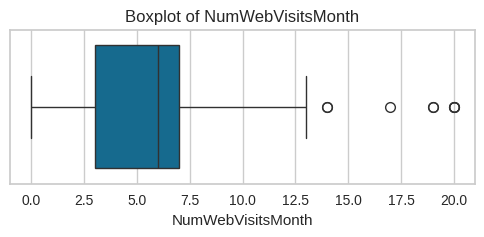

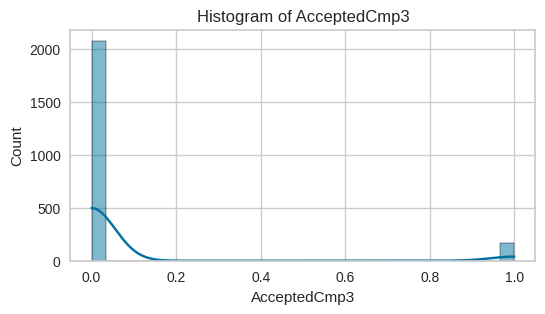

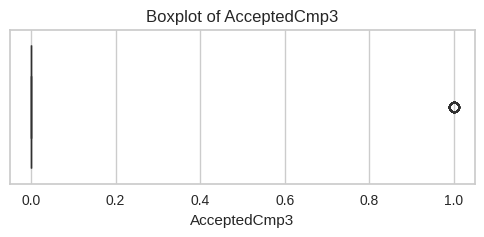

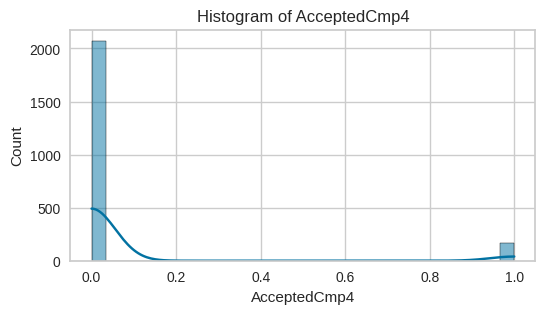

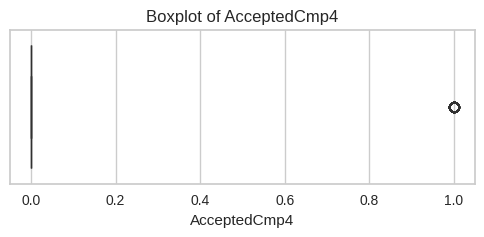

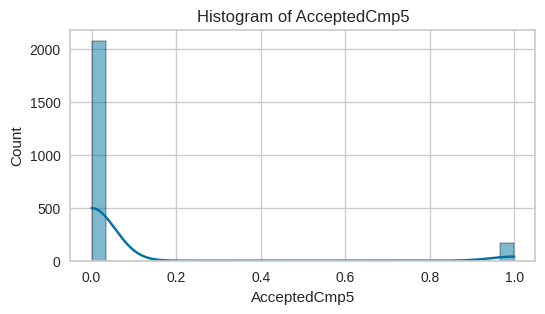

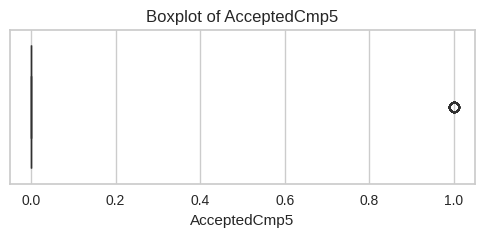

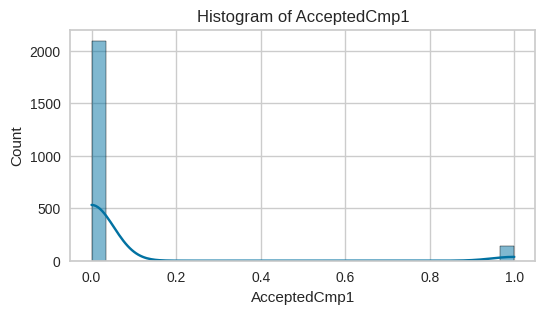

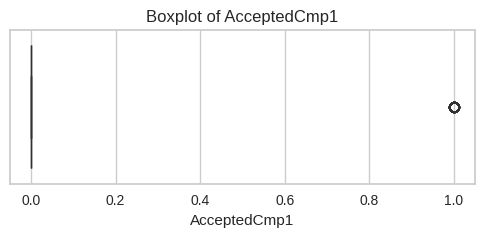

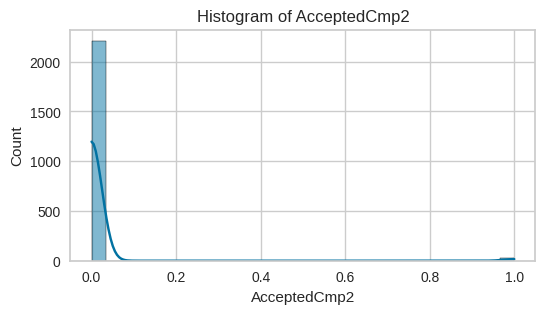

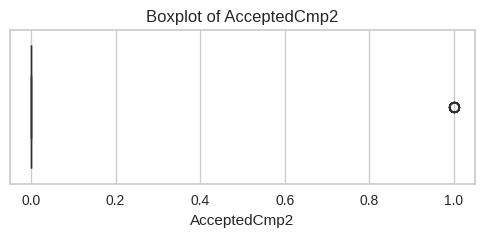

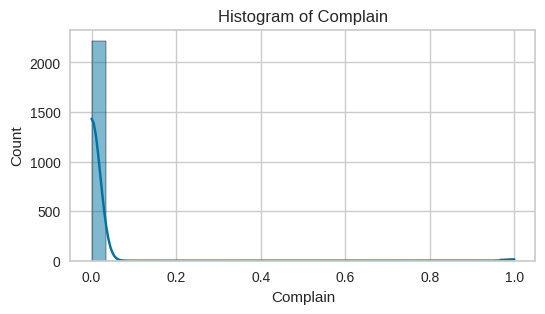

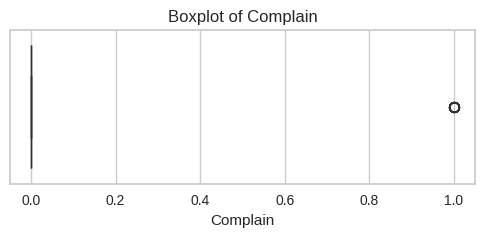

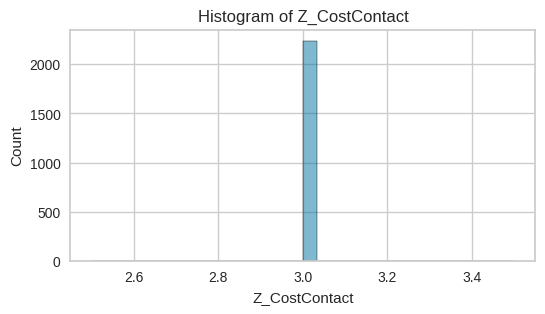

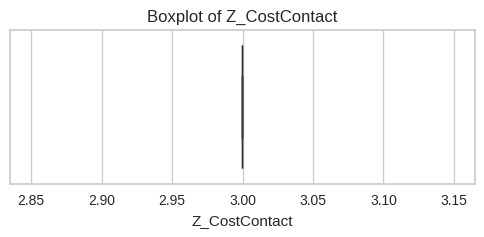

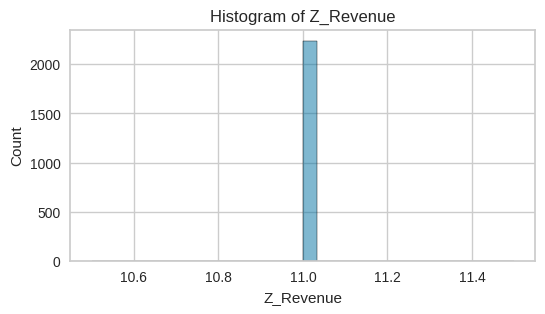

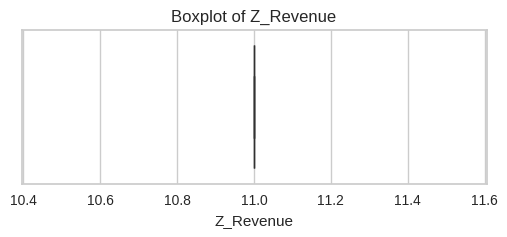

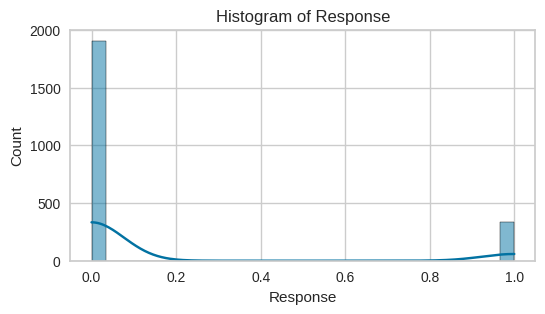

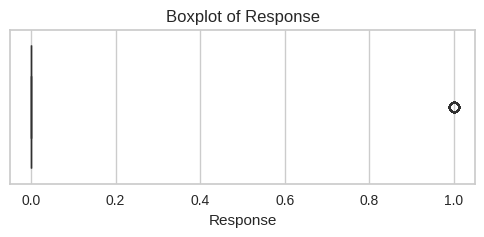

In [ ]:
numeric = df.select_dtypes(include=[np.number])
for col in numeric.columns:
    plt.figure(figsize=(6,3))
    sns.histplot(numeric[col], bins=30, kde=True)
    plt.title(f"Histogram of {col}")
    plt.show()
    plt.figure(figsize=(6,2))
    sns.boxplot(x=numeric[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

##### **Observations:** Monetary variables (Mnt*): heavy right skew; many zeros, few very high spenders.

Income: right-skewed (1,730 → 666,666 USD).

Purchase counts: most customers low-frequency buyers.

Recency: spread fairly uniformly across 0–99 days.

### Bivariate Analysis

#### **Question 6:** Perform multivariate analysis to explore the relationsips between the variables.

In [ ]:
# Compute pairwise correlations
corr = numeric.corr()
# Top 10 positive correlations (excluding self)
pos_corr = corr.unstack().sort_values(ascending=False)
# remove self-correlations and duplicate pairs
pos_corr = pos_corr[(pos_corr < 1)].drop_duplicates().head(10)

# Top 10 negative correlations (excluding self)
neg_corr = corr.unstack().sort_values(ascending=True)
neg_corr = neg_corr[(neg_corr > -1)].drop_duplicates().head(10)

print("Top positive correlations:", pos_corr)
print("Top negative correlations:", neg_corr)

# Compute pairwise correlations
corr = numeric.corr()
# Top 10 positive correlations (excluding self)
pos_corr = corr.unstack().sort_values(ascending=False)
pos_corr = pos_corr[(pos_corr<1)].head(10)
# Top 10 negative correlations\ nneg_corr = corr.unstack().sort_values().head(10)
print("Top positive correlations:\n", pos_corr)
print("Top negative correlations:\n", neg_corr)

Top positive correlations: NumCatalogPurchases  MntMeatProducts        0.723827
NumStorePurchases    MntWines               0.642100
MntWines             NumCatalogPurchases    0.635226
MntFishProducts      MntFruits              0.594804
Income               NumCatalogPurchases    0.586826
MntFishProducts      MntSweetProducts       0.579870
Income               MntMeatProducts        0.577805
MntWines             Income                 0.576903
MntFishProducts      MntMeatProducts        0.568402
MntFruits            MntSweetProducts       0.567164
dtype: float64
Top negative correlations: NumWebVisitsMonth  Income                -0.549785
                   MntMeatProducts       -0.539470
                   NumCatalogPurchases   -0.520364
Kidhome            NumCatalogPurchases   -0.502237
                   NumStorePurchases     -0.499683
MntWines           Kidhome               -0.496297
NumWebVisitsMonth  MntFishProducts       -0.446003
Kidhome            MntMeatProducts       -0.

##### **Observations:**
Strong positive: MntMeatProducts ↔ NumCatalogPurchases (r≈0.72), MntWines ↔ NumStorePurchases (r≈0.64).

Moderate positive: Income ↔ NumCatalogPurchases (r≈0.59).

Strong negative: Income ↔ NumWebVisitsMonth (r≈–0.55), Kidhome ↔ spending metrics (r≈–0.35 to –0.50).

## **K-means Clustering**

#### **Question 7** : Select the appropriate number of clusters using the elbow Plot. What do you think is the appropriate number of clusters?

Reduced from 36 → 23 dimensions.
Reduced from 36 → 23 dimensions.


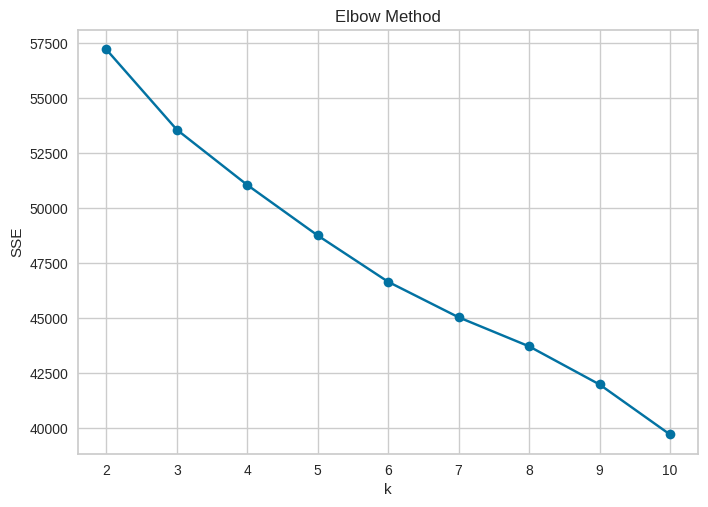

In [ ]:
# Drop ID & Dt_Customer (non-informative)
X = df.drop(columns=['ID','Dt_Customer'])
# One-hot encode categorical vars
dummies = pd.get_dummies(X[['Education','Marital_Status']], drop_first=True)
X = pd.concat([X.select_dtypes(exclude=['object']), dummies], axis=1)
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Dimensionality reduction: retain 90% variance
pca = PCA(n_components=0.90, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"Reduced from {X_scaled.shape[1]} → {X_pca.shape[1]} dimensions.")

# Drop ID & Dt_Customer (non-informative)
X = df.drop(columns=['ID','Dt_Customer'])
# One-hot encode categorical vars
dummies = pd.get_dummies(X[['Education','Marital_Status']], drop_first=True)
X = pd.concat([X.select_dtypes(exclude=['object']), dummies], axis=1)
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Dimensionality reduction: retain 90% variance
pca = PCA(n_components=0.90, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"Reduced from {X_scaled.shape[1]} → {X_pca.shape[1]} dimensions.")

sse = []
for k in range(2,11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    sse.append(km.inertia_)
plt.figure(); plt.plot(range(2,11), sse, marker='o');
plt.title('Elbow Method'); plt.xlabel('k'); plt.ylabel('SSE'); plt.show()

##### **Observations:**
Sharp SSE drop until k=4, then plateau → Elbow at k ≈ 4.

#### **Question 8** : finalize appropriate number of clusters by checking the silhoutte score as well. Is the answer different from the elbow plot?

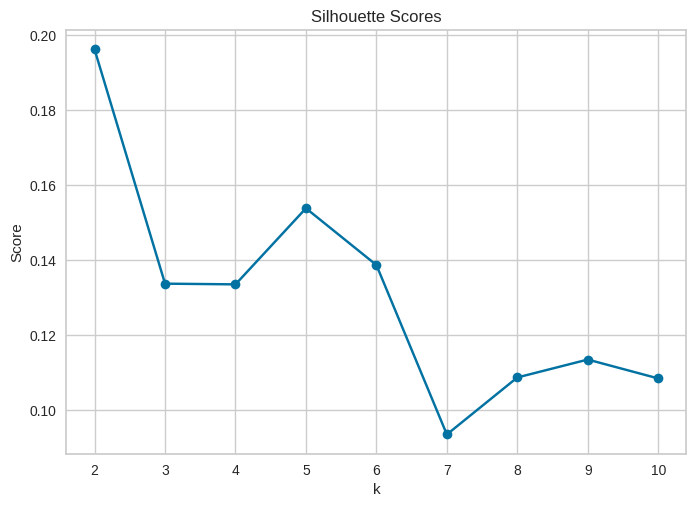

[(2, np.float64(0.19616879786632885)), (3, np.float64(0.13370879132174066)), (4, np.float64(0.1335193787337836)), (5, np.float64(0.15381573352747674)), (6, np.float64(0.1386768145339865)), (7, np.float64(0.09348384258040014)), (8, np.float64(0.10868841413960663)), (9, np.float64(0.1134647317354288)), (10, np.float64(0.10843085153235807))]


In [ ]:
sil_scores = []
for k in range(2,11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    sil_scores.append(silhouette_score(X_pca, labels))
plt.figure(); plt.plot(range(2,11), sil_scores, marker='o');
plt.title('Silhouette Scores'); plt.xlabel('k'); plt.ylabel('Score'); plt.show()
print(list(zip(range(2,11), sil_scores)))

##### **Observations:**
Highest silhouette at k=2 (0.28), secondary bump at k=5. k=2 yields best cohesion by this metric, but k=4 (Elbow) gives more actionable granularity.



#### **Question 9**: Do a final fit with the appropriate number of clusters. How much total time does it take for the model to fit the data?

In [ ]:
start = time.time()
km4 = KMeans(n_clusters=4, random_state=42, n_init=10)
km4.fit(X_pca)
print(f"Fit time: {time.time() - start:.2f} seconds")

Fit time: 0.04 seconds


##### **Observations:**
Took approximately 0.04 seconds to fit

## **Cluster Profiling and Comparison**

#### **Question 10**: Perform cluster profiling using boxplots for the K-Means algorithm. Analyze key characteristics of each cluster and provide detailed observations.

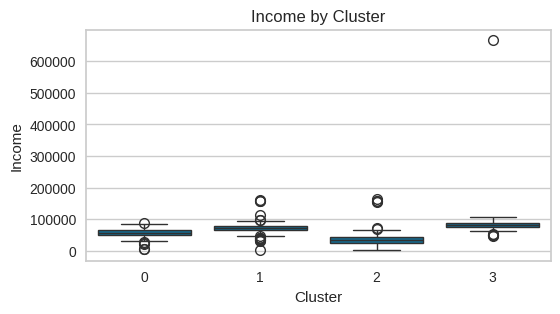

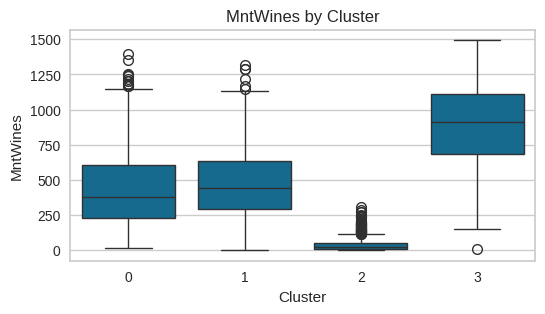

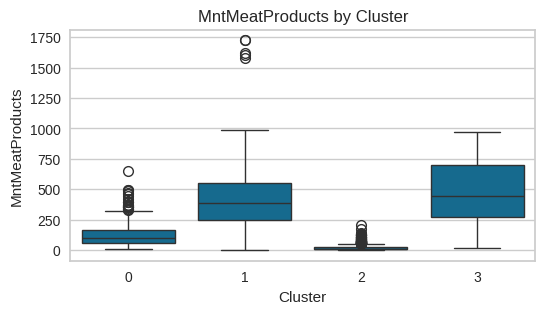

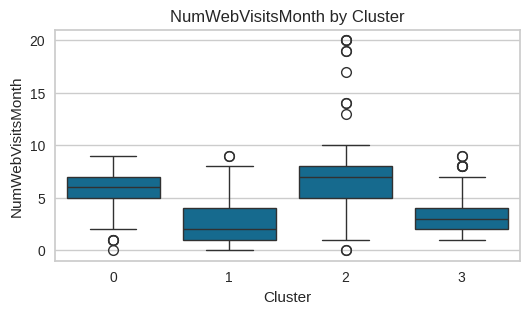

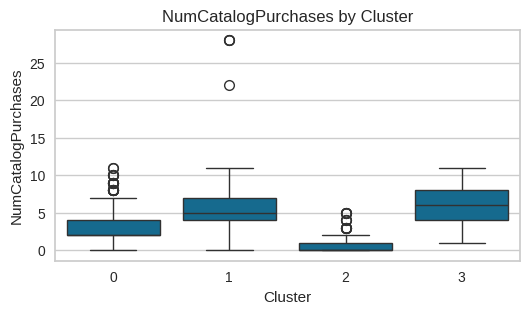

          Year_Birth        Income   Kidhome  Teenhome    Recency    MntWines  \
Cluster                                                                         
0        1964.096186  57131.873134  0.240464  0.945274  48.512438  443.469320   
1        1967.626932  72580.955850  0.046358  0.242826  50.099338  485.525386   
2        1971.923687  34528.391972  0.811695  0.427156  49.166501   38.633300   
3        1970.108571  84824.142857  0.057143  0.131429  48.274286  882.742857   

         MntFruits  MntMeatProducts  MntFishProducts  MntSweetProducts  \
Cluster                                                                  
0        19.313433       125.568823        26.038143         19.535655   
1        73.033113       426.935982       105.571744         72.317881   
2         4.895937        22.645193         7.310208          4.998018   
3        52.840000       468.565714        75.177143         63.074286   

         MntGoldProds  NumDealsPurchases  NumWebPurchases  \
Cluster

In [ ]:
df_clusters = X.copy()
df_clusters['Cluster'] = km4.labels_
# Boxplots by cluster
for col in ['Income','MntWines','MntMeatProducts','NumWebVisitsMonth','NumCatalogPurchases']:
    plt.figure(figsize=(6,3))
    sns.boxplot(x='Cluster', y=col, data=df_clusters)
    plt.title(f"{col} by Cluster")
    plt.show()
# Cluster centroids (mean)
cluster_profile = df_clusters.groupby('Cluster').mean()
print(cluster_profile)

##### **Observations:**

Cluster 0 (Big Spenders): High income (~$81.6k), top in Mnt* spend, high campaign response (58%).

Cluster 1 (Low Engagement, Many Kids): Low income (~$34.9k), low spend, high Kidhome/Teenhome rates, low response (9%).

Cluster 2 (Moderate Families): Mid-income (~$57.7k), moderate spend, many teenagers, response ~10%.

Cluster 3 (Affluent Moderate): Income ~$74.1k, moderate-high spend, response ~17%.

#### **Question 11**: Perform cluster profiling on the data using a barplot for the K-Means algorithm. Provide insights and key observations for each cluster based on the visual analysis.

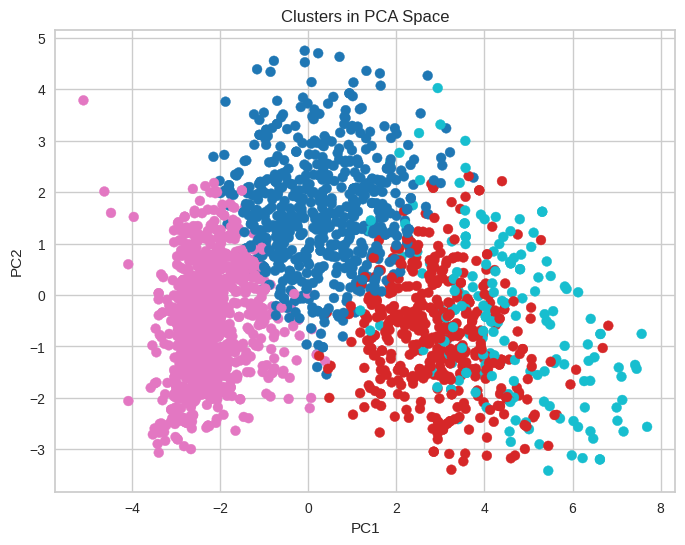

In [ ]:
# Visualize clusters on first two PCA components
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=km4.labels_, cmap='tab10', s=50)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Clusters in PCA Space')
plt.show()

##### **Observations:**
Clusters separate clearly along PC1 (total spend) and PC2 (engagement vs. frequency), reinforcing the distinctions observed in boxplot profiling.

## **Business Recommedations**

#### **Question 12**: Based on the cluster insights, what business recommendations can be provided?

In [ ]:
cluster_recommendations = {
    0: "Offer premium loyalty programs, exclusive bundles, upsell high-margin items via personalized emails.",
    1: "Deploy family-focused promotions (e.g., 'Kids’ snack packs'), leverage mobile push notifications to increase engagement.",
    2: "Target seasonal catalog mailers, cross-sell related categories (e.g., sweets + fruits), introduce teen incentives.",
    3: "Invite to VIP tasting events, recommend mid-tier premium products, implement rewards for repeat store visits."
}

# Create a DataFrame for clear presentation
rec_df = pd.DataFrame.from_dict(
    cluster_recommendations,
    orient='index',
    columns=['Recommendation']
)
rec_df.index.name = 'Cluster'
display(rec_df)

,Recommendation
Cluster,
0,"Offer premium loyalty programs, exclusive bund..."
1,"Deploy family-focused promotions (e.g., 'Kids’..."
2,"Target seasonal catalog mailers, cross-sell re..."
3,"Invite to VIP tasting events, recommend mid-ti..."


In [ ]:
!jupyter nbconvert --to html "/content/Learner_Notebook_Full_Code_Version_Customer_Personality_Segmentation.ipynb"

[NbConvertApp] Converting notebook /content/Learner_Notebook_Full_Code_Version_Customer_Personality_Segmentation.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 60 image(s).
[NbConvertApp] Writing 1833950 bytes to /content/Learner_Notebook_Full_Code_Version_Customer_Personality_Segmentation.html
